#LSTM2

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

ticker = 'TSLA'
start_date = '2020-01-01'
end_date = '2025-07-16'
model_path = "best_lstm_model_procedural.h5"

train_ratio = 0.7
val_ratio = 0.15




In [ ]:
#  DATA PREPARATION 
print(f"Downloading historical data for {ticker}...")
stock_df = yf.download(ticker, start=start_date, end=end_date)

print("Downloading market data (^GSPC, ^VIX)...")
market_df = yf.download(['^GSPC', '^VIX'], start=stock_df.index.min(), end=stock_df.index.max())

# Combine the data
combined_df = pd.concat([stock_df[['Close', 'Volume', 'High', 'Low']], market_df['Close'][['^GSPC', '^VIX']]], axis=1)
combined_df.columns = ['TSLA_Close', 'TSLA_Volume', 'TSLA_High', 'TSLA_Low', 'SP500_Close', 'VIX_Close']
combined_df.dropna(inplace=True)
print("Data download complete.")

/tmp/ipython-input-2450469595.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2450469595.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_df = yf.download(['^GSPC', '^VIX'], start=stock_df.index.min(), end=stock_df.index.max())
[*********************100%***********************]  2 of 2 completed

Data download complete.


In [ ]:
# FEATURE ENGINEERING 
print("\nEngineering advanced features...")

#  Returns 
combined_df['TSLA_Return'] = combined_df['TSLA_Close'].pct_change()
combined_df['SP500_Return'] = combined_df['SP500_Close'].pct_change()
#  Volatility
combined_df['Volatility_21d'] = combined_df['TSLA_Return'].rolling(window=21).std() * np.sqrt(21)

# Trend Indicators
sma_50 = combined_df['TSLA_Close'].rolling(window=50).mean()
combined_df['Price_vs_SMA50'] = (combined_df['TSLA_Close'] - sma_50) / sma_50

# Momentum Indicators
delta = combined_df['TSLA_Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
combined_df['RSI_14'] = 100 - (100 / (1 + rs))

ema_fast = combined_df['TSLA_Close'].ewm(span=12, adjust=False).mean()
ema_slow = combined_df['TSLA_Close'].ewm(span=26, adjust=False).mean()
combined_df['MACD'] = ema_fast - ema_slow
combined_df['MACD_Signal'] = combined_df['MACD'].ewm(span=9, adjust=False).mean()

#  On-Balance Volume (OBV)
combined_df['OBV'] = (np.sign(combined_df['TSLA_Close'].diff()) * combined_df['TSLA_Volume']).fillna(0).cumsum()

# Volatility Indicator  (ATR)
tr1 = combined_df['TSLA_High'] - combined_df['TSLA_Low']
tr2 = abs(combined_df['TSLA_High'] - combined_df['TSLA_Close'].shift())
tr3 = abs(combined_df['TSLA_Low'] - combined_df['TSLA_Close'].shift())
tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
combined_df['ATR_14'] = tr.ewm(span=14, adjust=False).mean()

# Lagged Features
combined_df['TSLA_Return_Lag1'] = combined_df['TSLA_Return'].shift(1)
combined_df['SP500_Return_Lag1'] = combined_df['SP500_Return'].shift(1)

# Drop rows with NaN values
featured_df = combined_df.dropna().copy()
print("Feature engineering complete.")



Engineering advanced features...
Feature engineering complete.


In [ ]:


# features to be used
features_list = [
    'TSLA_Close', 'TSLA_Volume', 'SP500_Close', 'VIX_Close',
    'Volatility_21d', 'Price_vs_SMA50', 'RSI_14', 'MACD',
    'MACD_Signal', 'OBV', 'ATR_14', 'TSLA_Return_Lag1', 'SP500_Return_Lag1'
]
dataset_for_scaling = featured_df[features_list].values

# Split data
total_size = len(dataset_for_scaling)
train_end_idx = int(total_size * train_ratio)
val_end_idx = train_end_idx + int(total_size * val_ratio)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit the scaler on the training
scaler.fit(dataset_for_scaling[0:train_end_idx])
# the entire dataset
scaled_dataset = scaler.transform(dataset_for_scaling)

#  data subsets from the scaled data
train_data = scaled_dataset[0:train_end_idx]
val_data = scaled_dataset[train_end_idx - look_back : val_end_idx]
test_data = scaled_dataset[val_end_idx - look_back:]

#  function to create sequences
def create_sequences(data, look_back_period):
    X, y = [], []
    for i in range(look_back_period, len(data)):
        X.append(data[i-look_back_period:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

#  final X, y sequences
X_train, y_train = create_sequences(train_data, look_back)
X_val, y_val = create_sequences(val_data, look_back)
X_test, y_test = create_sequences(test_data, look_back)

print(f"\nTraining set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape:       {X_test.shape}")



Preparing data for LSTM...
Fitting scaler on training data and transforming the dataset...

Training set shape:   (877, 60, 13)
Validation set shape: (201, 60, 13)
Test set shape:       (202, 60, 13)


In [ ]:
# Model parameters
look_back = 60
lstm_units = 100
dropout_rate = 0.2
epochs = 100
batch_size = 16

In [ ]:
from tensorflow.keras.optimizers import Adam
# MODEL 

model = Sequential([
    LSTM(units=lstm_units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(dropout_rate),
    LSTM(units=lstm_units, return_sequences=False),
    Dropout(dropout_rate),
    Dense(units=1)
])

# Compile the model
optimizer = Adam(learning_rate= 0.0005)

model.compile(optimizer, loss='mean_squared_error')
model.summary()

# Define callbacks  trainin
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint(model_path, monitor='val_loss', save_best_only=True)
]

# Train
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)



Building the LSTM model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        45,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,101 (492.58 KB)

...

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0041 - val_loss: 0.0032
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0036 - val_loss: 0.0083
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0037 - val_loss: 0.0039
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0033 - val_loss: 0.0057
Epoch 12/100
53/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036 - val_loss: 0.0023
Epoch 13/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0035 - val_loss: 0.0072
Epoch 14/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0035 - val_loss: 0.0026
Epoch 15/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0026 - val_loss: 0.0040
Epoch 16/100
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 17/100
52/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 18/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0029 - val_loss: 0.0050
Epoch 19/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 20/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0023 - val_loss: 0.0013
Epoch 21/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 22/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0025

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0025 - val_loss: 8.9260e-04
Epoch 23/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 24/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 25/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0024 - val_loss: 0.0050
Epoch 26/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0025 - val_loss: 0.0034
Epoch 27/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 28/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 29/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 30/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0022 - val_loss: 0.0028
Epoch 31/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 32/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0021 - val_loss: 0.0026
Model training complete.



--- Model Evaluation ---


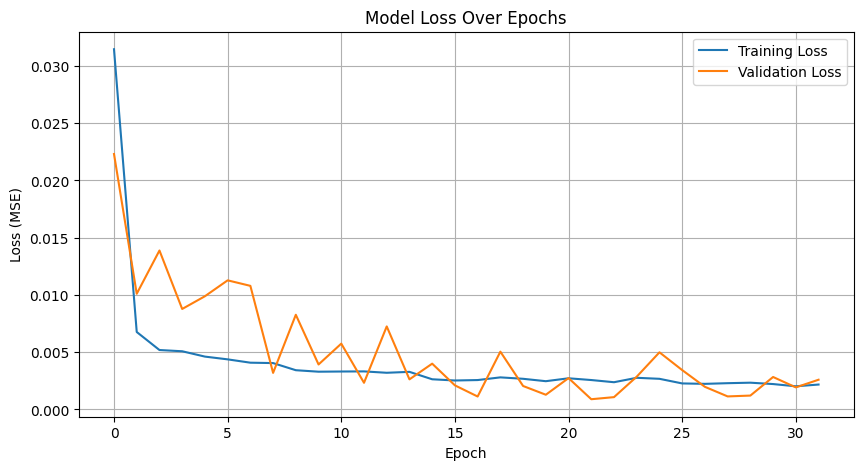

Loading best model from: best_lstm_model_procedural.h5
Making predictions on the test set...


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

--- Test Set Performance Metrics ---
Root Mean Squared Error (RMSE): $21.62
Mean Absolute Error (MAE):    $16.40
Mean Absolute Percentage Error (MAPE): 5.21%
------------------------------------



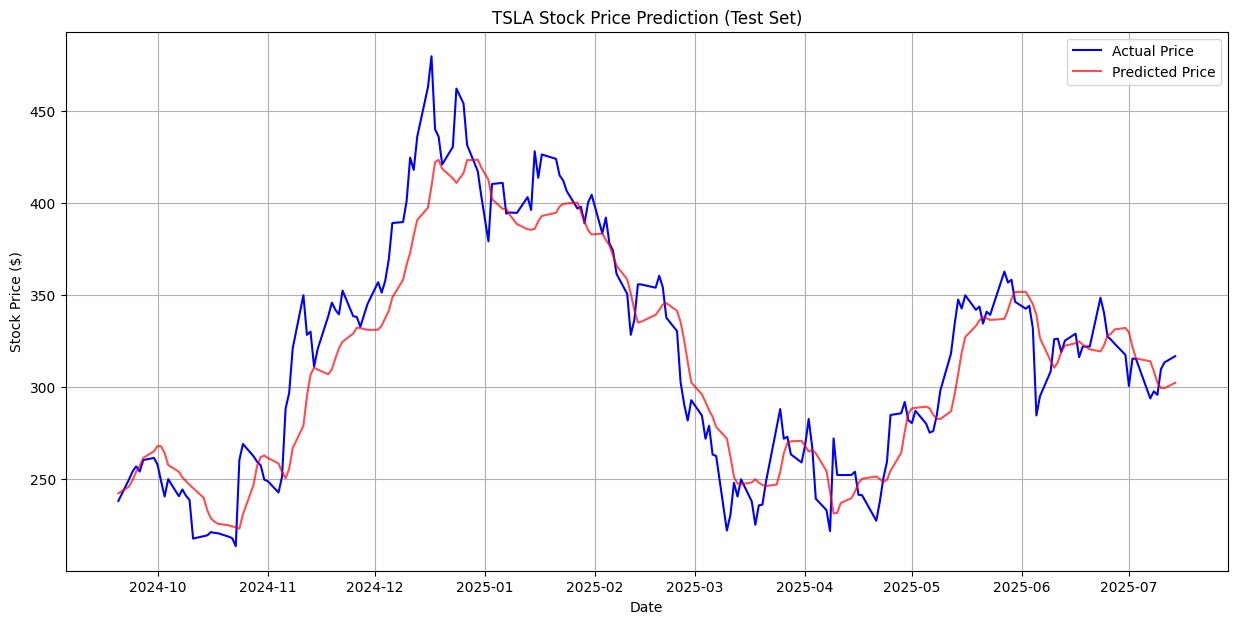

In [ ]:
# EVALUATE

#  training & validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

#  best performing model saved by ModelCheckpoint
print(f"best model  {model_path}")
best_model = load_model(model_path)

# predictions 
predictions_scaled = best_model.predict(X_test)

dummy_predictions = np.zeros((len(predictions_scaled), len(features_list)))
dummy_predictions[:, 0] = predictions_scaled.ravel()
predictions = scaler.inverse_transform(dummy_predictions)[:, 0]

actuals = featured_df['TSLA_Close'].values[val_end_idx:]

min_len = min(len(predictions), len(actuals))
predictions = predictions[:min_len]
actuals = actuals[:min_len]

mae = mean_absolute_error(actuals, predictions)
mape = mean_absolute_percentage_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))


print("\n--- Test Set Performance Metrics ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error (MAE):    ${mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%}")

print("------------------------------------\n")

dates = featured_df.index[val_end_idx:][:min_len]
plt.figure(figsize=(15, 7))
plt.plot(dates, actuals, color='blue', label='Actual Price')
plt.plot(dates, predictions, color='red', alpha=0.7, label='Predicted Price')
plt.title(f'{ticker} Stock Price Prediction (Test Set)')
plt.xlabel('Date')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True)
plt.show()